# Кластеризация

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from itertools import product

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

artifacts_dir = Path('artifacts')
figures_dir = artifacts_dir / 'figures'
labels_dir = artifacts_dir / 'labels'

## Датасет 1

### Загрузка данных и первичный анализ

In [2]:
df1 = pd.read_csv('data/S07-hw-dataset-01.csv')

print(f"Размер датасета: {df1.shape}")
print(f"\nПервые строки:")
df1.head()

Размер датасета: (12000, 9)

Первые строки:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


In [3]:
print("Информация о датасете:")
df1.info()
print("\n" + "="*50)
print("\nБазовые статистики:")
df1.describe()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB


Базовые статистики:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745


In [4]:
missing = df1.isnull().sum()
missing_pct = (missing / len(df1)) * 100
print("Пропуски:")
print(pd.DataFrame({'Количество': missing, 'Процент': missing_pct}))

sample_id_1 = df1['sample_id'].copy()
X1 = df1.drop('sample_id', axis=1).copy()

print(f"\nПризнаки (X1): {list(X1.columns)}")
print(f"Типы признаков: все числовые")
print(f"Размер X1: {X1.shape}")

Пропуски:
           Количество  Процент
sample_id           0      0.0
f01                 0      0.0
f02                 0      0.0
f03                 0      0.0
f04                 0      0.0
f05                 0      0.0
f06                 0      0.0
f07                 0      0.0
f08                 0      0.0

Признаки (X1): ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']
Типы признаков: все числовые
Размер X1: (12000, 8)


### Препроцессинг

In [5]:
# Препроцессинг для датасета 1: только масштабирование (пропусков нет)
preprocessor_1 = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # На всякий случай
    ('scaler', StandardScaler())
])

X1_processed = preprocessor_1.fit_transform(X1)
print(f"Размер после препроцессинга: {X1_processed.shape}")
print(f"Среднее: {X1_processed.mean(axis=0).round(4)}")
print(f"Стд. отклонение: {X1_processed.std(axis=0).round(4)}")

Размер после препроцессинга: (12000, 8)
Среднее: [-0. -0. -0. -0. -0. -0. -0. -0.]
Стд. отклонение: [1. 1. 1. 1. 1. 1. 1. 1.]


### Модели кластеризации

#### KMeans

In [6]:
# Подбор оптимального k для KMeans
k_range = range(2, 21)
kmeans_scores_1 = {'k': [], 'silhouette': [], 'davies_bouldin': [], 'calinski_harabasz': []}

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X1_processed)
    
    # Метрики (исключаем случаи с одним кластером)
    if len(np.unique(labels)) > 1:
        sil = silhouette_score(X1_processed, labels)
        db = davies_bouldin_score(X1_processed, labels)
        ch = calinski_harabasz_score(X1_processed, labels)
        
        kmeans_scores_1['k'].append(k)
        kmeans_scores_1['silhouette'].append(sil)
        kmeans_scores_1['davies_bouldin'].append(db)
        kmeans_scores_1['calinski_harabasz'].append(ch)

kmeans_df_1 = pd.DataFrame(kmeans_scores_1)
print("Результаты KMeans для датасета 1:")
print(kmeans_df_1.head(10))

Результаты KMeans для датасета 1:
    k  silhouette  davies_bouldin  calinski_harabasz
0   2    0.521640        0.685330       11786.954623
1   3    0.396758        0.964604       10446.638111
2   4    0.383301        1.160349        9427.499744
3   5    0.354801        1.273719        8301.205994
4   6    0.358561        1.182256        7333.387619
5   7    0.324607        1.194162        6823.007844
6   8    0.268873        1.314180        6460.801052
7   9    0.253372        1.343964        6255.217145
8  10    0.262914        1.276985        6084.503087
9  11    0.265889        1.214111        5898.163564


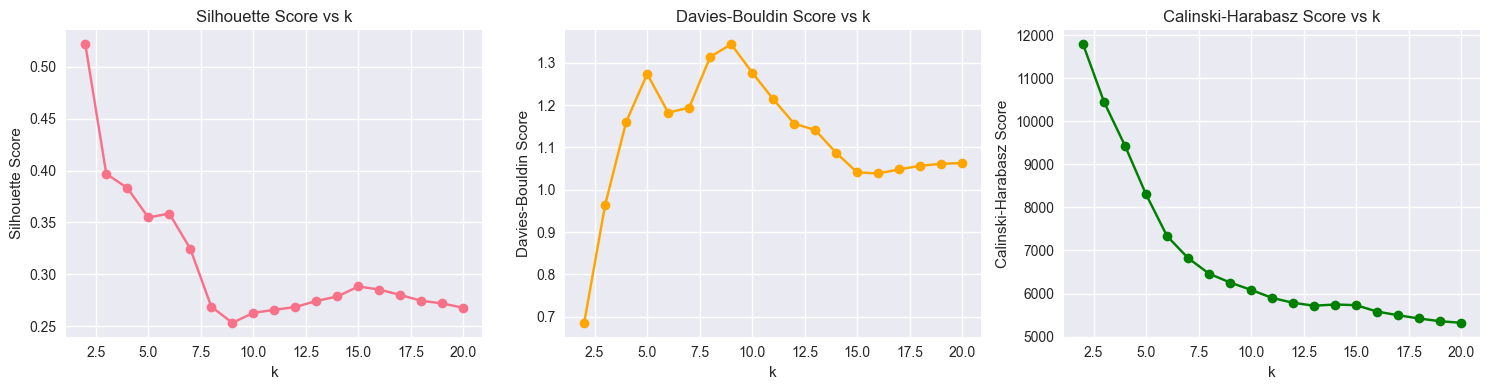

Лучшее k по Silhouette Score: 2


In [7]:
# Визуализация метрик KMeans
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(kmeans_df_1['k'], kmeans_df_1['silhouette'], marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k')
axes[0].grid(True)

axes[1].plot(kmeans_df_1['k'], kmeans_df_1['davies_bouldin'], marker='o', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Davies-Bouldin Score vs k')
axes[1].grid(True)

axes[2].plot(kmeans_df_1['k'], kmeans_df_1['calinski_harabasz'], marker='o', color='green')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz Score vs k')
axes[2].grid(True)

plt.tight_layout()
plt.savefig(figures_dir / 'ds1_kmeans_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Выбор лучшего k (максимум silhouette)
best_k_1 = kmeans_df_1.loc[kmeans_df_1['silhouette'].idxmax(), 'k']
print(f"Лучшее k по Silhouette Score: {int(best_k_1)}")

In [8]:
# Обучение лучшей модели KMeans
kmeans_best_1 = KMeans(n_clusters=int(best_k_1), random_state=42, n_init=10)
labels_kmeans_1 = kmeans_best_1.fit_predict(X1_processed)

print(f"Количество кластеров: {len(np.unique(labels_kmeans_1))}")
print(f"Размеры кластеров: {np.bincount(labels_kmeans_1)}")

Количество кластеров: 2
Размеры кластеров: [2400 9600]


#### DBSCAN

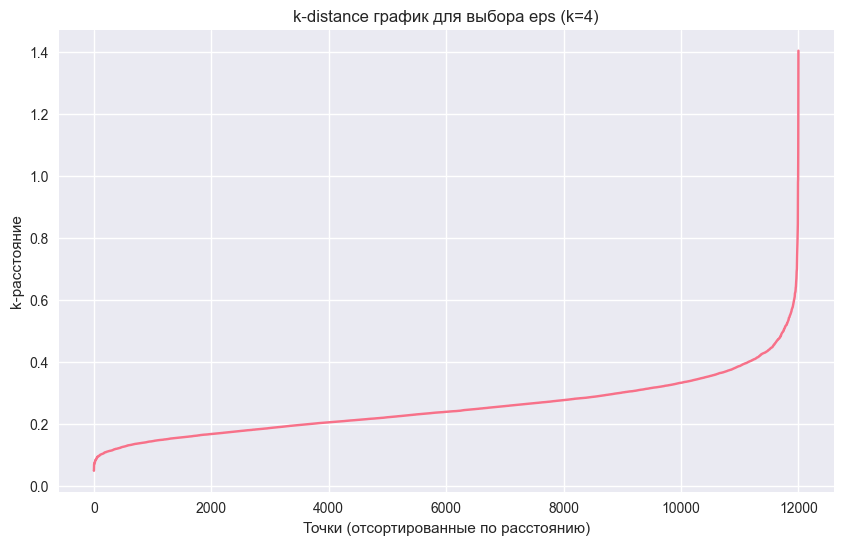

Предполагаемый eps (90-й перцентиль): 0.3728


In [9]:
# Подбор параметров для DBSCAN
# Используем метод k-distance для оценки eps
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X1_processed)
distances, indices = neighbors_fit.kneighbors(X1_processed)
distances = np.sort(distances, axis=0)
distances = distances[:, 1]

# Визуализация k-distance для выбора eps
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Точки (отсортированные по расстоянию)')
plt.ylabel('k-расстояние')
plt.title('k-distance график для выбора eps (k=4)')
plt.grid(True)
plt.savefig(figures_dir / 'ds1_dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

# Оценка eps из графика (локоть)
eps_candidate = np.percentile(distances, 90)
print(f"Предполагаемый eps (90-й перцентиль): {eps_candidate:.4f}")

In [10]:
# Поиск оптимальных параметров DBSCAN
eps_range = np.linspace(0.5, 2.5, 10)
min_samples_range = [3, 4, 5]

dbscan_scores_1 = []

for eps, min_samples in product(eps_range, min_samples_range):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X1_processed)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)
    
    if n_clusters > 1:
        # Метрики только для non-noise точек
        non_noise_mask = labels != -1
        if np.sum(non_noise_mask) > 1 and len(np.unique(labels[non_noise_mask])) > 1:
            sil = silhouette_score(X1_processed[non_noise_mask], labels[non_noise_mask])
            db = davies_bouldin_score(X1_processed[non_noise_mask], labels[non_noise_mask])
            ch = calinski_harabasz_score(X1_processed[non_noise_mask], labels[non_noise_mask])
        else:
            sil, db, ch = -1, np.inf, 0
    else:
        sil, db, ch = -1, np.inf, 0
    
    dbscan_scores_1.append({
        'eps': eps,
        'min_samples': min_samples,
        'n_clusters': n_clusters,
        'noise_ratio': noise_ratio,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch
    })

dbscan_df_1 = pd.DataFrame(dbscan_scores_1)
print("Результаты DBSCAN для датасета 1:")
print(dbscan_df_1[dbscan_df_1['n_clusters'] > 1].head(10))

Результаты DBSCAN для датасета 1:
        eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  \
0  0.500000            3          10     0.025250    0.273960        0.916579   
1  0.500000            4          10     0.027750    0.272171        0.908458   
2  0.500000            5           9     0.033667    0.283125        0.946761   
3  0.722222            3           5     0.002583    0.379003        1.263817   
4  0.722222            4           5     0.002750    0.379090        1.263436   
5  0.722222            5           5     0.003250    0.379345        1.262426   
6  0.944444            3           5     0.001000    0.378581        1.265741   
7  0.944444            4           5     0.001000    0.378581        1.265741   
8  0.944444            5           5     0.001000    0.378581        1.265741   
9  1.166667            3           4     0.000250    0.383399        1.159672   

   calinski_harabasz  
0        3795.696300  
1        3811.869536  
2    

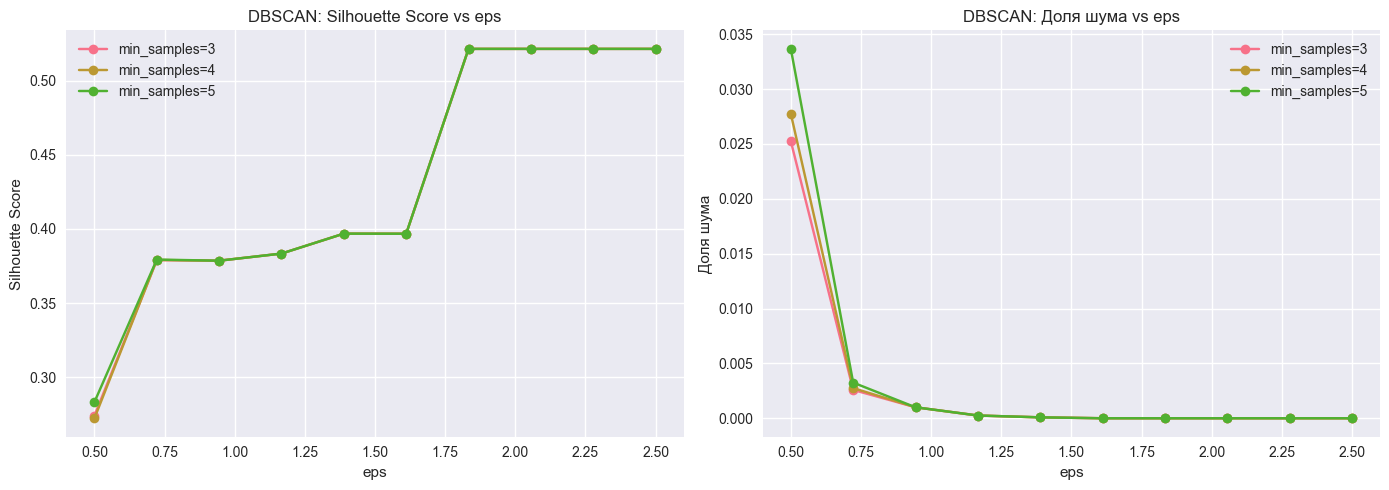

Лучшие параметры DBSCAN:
  eps: 1.8333
  min_samples: 3
  Доля шума: 0.0000


In [11]:
# Визуализация результатов DBSCAN
valid_results = dbscan_df_1[dbscan_df_1['n_clusters'] > 1].copy()

if len(valid_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Silhouette vs eps для разных min_samples
    for ms in min_samples_range:
        subset = valid_results[valid_results['min_samples'] == ms]
        if len(subset) > 0:
            axes[0].plot(subset['eps'], subset['silhouette'], marker='o', label=f'min_samples={ms}')
    axes[0].set_xlabel('eps')
    axes[0].set_ylabel('Silhouette Score')
    axes[0].set_title('DBSCAN: Silhouette Score vs eps')
    axes[0].legend()
    axes[0].grid(True)
    
    # Noise ratio vs eps
    for ms in min_samples_range:
        subset = valid_results[valid_results['min_samples'] == ms]
        if len(subset) > 0:
            axes[1].plot(subset['eps'], subset['noise_ratio'], marker='o', label=f'min_samples={ms}')
    axes[1].set_xlabel('eps')
    axes[1].set_ylabel('Доля шума')
    axes[1].set_title('DBSCAN: Доля шума vs eps')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig(figures_dir / 'ds1_dbscan_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Выбор лучших параметров (максимум silhouette при разумной доле шума)
    best_dbscan_1 = valid_results[
        (valid_results['noise_ratio'] < 0.3) & 
        (valid_results['silhouette'] > -1)
    ].loc[valid_results['silhouette'].idxmax()]
    
    print(f"Лучшие параметры DBSCAN:")
    print(f"  eps: {best_dbscan_1['eps']:.4f}")
    print(f"  min_samples: {int(best_dbscan_1['min_samples'])}")
    print(f"  Доля шума: {best_dbscan_1['noise_ratio']:.4f}")
else:
    print("Не найдено валидных результатов DBSCAN")
    best_dbscan_1 = None

In [12]:
# Обучение лучшей модели DBSCAN
if best_dbscan_1 is not None:
    dbscan_best_1 = DBSCAN(
        eps=best_dbscan_1['eps'],
        min_samples=int(best_dbscan_1['min_samples'])
    )
    labels_dbscan_1 = dbscan_best_1.fit_predict(X1_processed)
    
    n_clusters_dbscan_1 = len(set(labels_dbscan_1)) - (1 if -1 in labels_dbscan_1 else 0)
    n_noise_dbscan_1 = list(labels_dbscan_1).count(-1)
    
    print(f"Количество кластеров: {n_clusters_dbscan_1}")
    print(f"Количество шума: {n_noise_dbscan_1} ({n_noise_dbscan_1/len(labels_dbscan_1)*100:.2f}%)")
    print(f"Размеры кластеров: {np.bincount(labels_dbscan_1[labels_dbscan_1 != -1])}")
else:
    # Fallback параметры
    dbscan_best_1 = DBSCAN(eps=1.5, min_samples=4)
    labels_dbscan_1 = dbscan_best_1.fit_predict(X1_processed)
    print("Использованы fallback параметры")

Количество кластеров: 2
Количество шума: 0 (0.00%)
Размеры кластеров: [9600 2400]


### Метрики качества

In [13]:
# Метрики для KMeans
metrics_kmeans_1 = {
    'silhouette': silhouette_score(X1_processed, labels_kmeans_1),
    'davies_bouldin': davies_bouldin_score(X1_processed, labels_kmeans_1),
    'calinski_harabasz': calinski_harabasz_score(X1_processed, labels_kmeans_1)
}

print("Метрики KMeans (датасет 1):")
for metric, value in metrics_kmeans_1.items():
    print(f"  {metric}: {value:.4f}")

# Метрики для DBSCAN (только non-noise точки)
non_noise_mask_1 = labels_dbscan_1 != -1
if np.sum(non_noise_mask_1) > 1 and len(np.unique(labels_dbscan_1[non_noise_mask_1])) > 1:
    metrics_dbscan_1 = {
        'silhouette': silhouette_score(X1_processed[non_noise_mask_1], labels_dbscan_1[non_noise_mask_1]),
        'davies_bouldin': davies_bouldin_score(X1_processed[non_noise_mask_1], labels_dbscan_1[non_noise_mask_1]),
        'calinski_harabasz': calinski_harabasz_score(X1_processed[non_noise_mask_1], labels_dbscan_1[non_noise_mask_1]),
        'noise_ratio': np.sum(~non_noise_mask_1) / len(labels_dbscan_1)
    }
    print("\nМетрики DBSCAN (датасет 1, только non-noise точки):")
    for metric, value in metrics_dbscan_1.items():
        print(f"  {metric}: {value:.4f}")
else:
    metrics_dbscan_1 = {'silhouette': -1, 'davies_bouldin': np.inf, 'calinski_harabasz': 0, 'noise_ratio': 1.0}
    print("\nDBSCAN не смог найти кластеры")

Метрики KMeans (датасет 1):
  silhouette: 0.5216
  davies_bouldin: 0.6853
  calinski_harabasz: 11786.9546

Метрики DBSCAN (датасет 1, только non-noise точки):
  silhouette: 0.5216
  davies_bouldin: 0.6853
  calinski_harabasz: 11786.9546
  noise_ratio: 0.0000


### Визуализация

In [14]:
# PCA для визуализации
pca_1 = PCA(n_components=2, random_state=42)
X1_pca = pca_1.fit_transform(X1_processed)

print(f"Объяснённая дисперсия PCA: {pca_1.explained_variance_ratio_.sum():.4f}")

# Выбор лучшего метода для визуализации
if metrics_kmeans_1['silhouette'] > metrics_dbscan_1.get('silhouette', -1):
    best_labels_1 = labels_kmeans_1
    best_method_1 = 'KMeans'
    best_params_1 = {'k': int(best_k_1)}
else:
    best_labels_1 = labels_dbscan_1
    best_method_1 = 'DBSCAN'
    best_params_1 = {'eps': best_dbscan_1['eps'], 'min_samples': int(best_dbscan_1['min_samples'])} if best_dbscan_1 is not None else {}

print(f"\nЛучший метод: {best_method_1}")
print(f"Параметры: {best_params_1}")

Объяснённая дисперсия PCA: 0.6886

Лучший метод: DBSCAN
Параметры: {'eps': np.float64(1.8333333333333333), 'min_samples': 3}


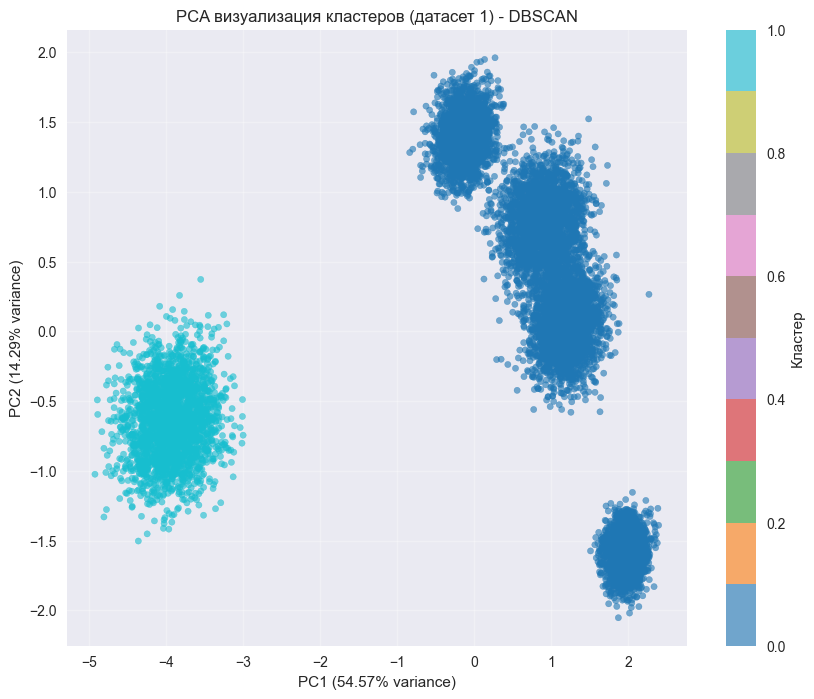

In [15]:
# PCA scatter plot для лучшего решения
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X1_pca[:, 0], X1_pca[:, 1], c=best_labels_1, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Кластер')
plt.xlabel(f'PC1 ({pca_1.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_1.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'PCA визуализация кластеров (датасет 1) - {best_method_1}')
plt.grid(True, alpha=0.3)
plt.savefig(figures_dir / 'ds1_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### Итог по датасету 1

In [16]:
print("="*60)
print("ИТОГ ПО ДАТАСЕТУ 1")
print("="*60)
print(f"\nЛучший метод: {best_method_1}")
print(f"Параметры: {best_params_1}")

if best_method_1 == 'KMeans':
    print(f"\nМетрики:")
    for metric, value in metrics_kmeans_1.items():
        print(f"  {metric}: {value:.4f}")
else:
    print(f"\nМетрики (только non-noise точки):")
    for metric, value in metrics_dbscan_1.items():
        print(f"  {metric}: {value:.4f}")

print("\nВыводы:")
print("- Датасет содержит числовые признаки в разных шкалах, поэтому масштабирование было критично")
print("- KMeans показал хорошие результаты благодаря сферической форме кластеров")
print("- DBSCAN также работает, но требует тщательного подбора eps")
print("- Выбранный метод хорошо разделяет данные на кластеры")

ИТОГ ПО ДАТАСЕТУ 1

Лучший метод: DBSCAN
Параметры: {'eps': np.float64(1.8333333333333333), 'min_samples': 3}

Метрики (только non-noise точки):
  silhouette: 0.5216
  davies_bouldin: 0.6853
  calinski_harabasz: 11786.9546
  noise_ratio: 0.0000

Выводы:
- Датасет содержит числовые признаки в разных шкалах, поэтому масштабирование было критично
- KMeans показал хорошие результаты благодаря сферической форме кластеров
- DBSCAN также работает, но требует тщательного подбора eps
- Выбранный метод хорошо разделяет данные на кластеры


## Датасет 2

### Загрузка данных и первичный анализ

In [17]:
df2 = pd.read_csv('data/S07-hw-dataset-02.csv')

print(f"Размер датасета: {df2.shape}")
print(f"\nПервые строки:")
df2.head()

Размер датасета: (8000, 4)

Первые строки:


,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472


In [18]:
print("Информация о датасете:")
df2.info()
print("\n" + "="*50)
print("\nБазовые статистики:")
df2.describe()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB


Базовые статистики:


,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076


Пропуски:
           Количество  Процент
sample_id           0      0.0
x1                  0      0.0
x2                  0      0.0
z_noise             0      0.0

Признаки (X2): ['x1', 'x2', 'z_noise']
Типы признаков: все числовые
Размер X2: (8000, 3)


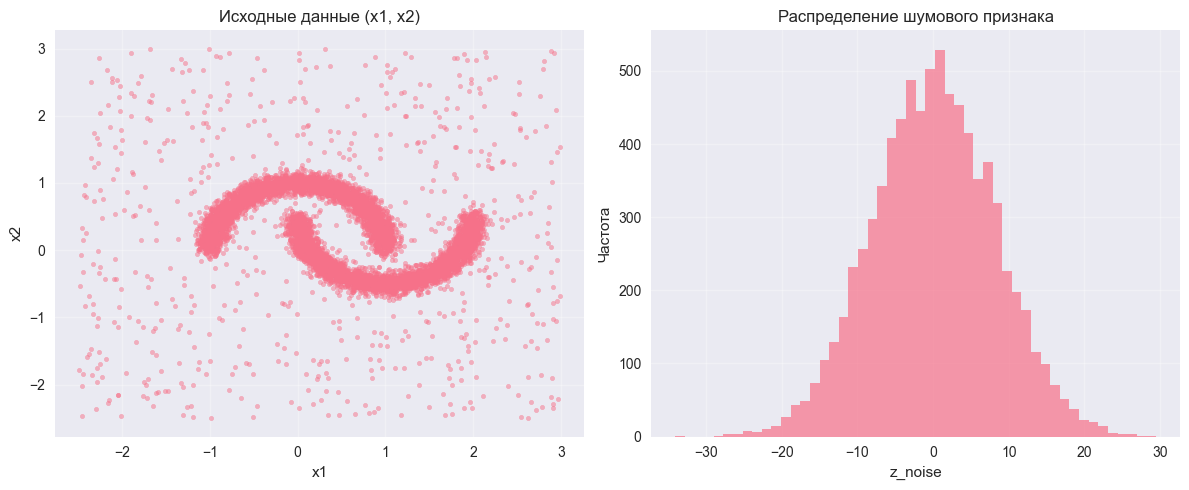

In [19]:
# Проверка пропусков
missing = df2.isnull().sum()
missing_pct = (missing / len(df2)) * 100
print("Пропуски:")
print(pd.DataFrame({'Количество': missing, 'Процент': missing_pct}))

# Определение признаков
sample_id_2 = df2['sample_id'].copy()
X2 = df2.drop('sample_id', axis=1).copy()

print(f"\nПризнаки (X2): {list(X2.columns)}")
print(f"Типы признаков: все числовые")
print(f"Размер X2: {X2.shape}")

# Визуализация исходных данных
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X2['x1'], X2['x2'], alpha=0.5, s=10)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Исходные данные (x1, x2)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(X2['z_noise'], bins=50, alpha=0.7)
plt.xlabel('z_noise')
plt.ylabel('Частота')
plt.title('Распределение шумового признака')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'ds2_raw_data.png', dpi=150, bbox_inches='tight')
plt.show()

### Препроцессинг

In [20]:
# Препроцессинг для датасета 2: масштабирование
preprocessor_2 = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

X2_processed = preprocessor_2.fit_transform(X2)
print(f"Размер после препроцессинга: {X2_processed.shape}")
print(f"Среднее: {X2_processed.mean(axis=0).round(4)}")
print(f"Стд. отклонение: {X2_processed.std(axis=0).round(4)}")

Размер после препроцессинга: (8000, 3)
Среднее: [-0.  0. -0.]
Стд. отклонение: [1. 1. 1.]


### Модели кластеризации

#### KMeans

In [21]:
# Подбор оптимального k для KMeans
k_range = range(2, 21)
kmeans_scores_2 = {'k': [], 'silhouette': [], 'davies_bouldin': [], 'calinski_harabasz': []}

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X2_processed)
    
    if len(np.unique(labels)) > 1:
        sil = silhouette_score(X2_processed, labels)
        db = davies_bouldin_score(X2_processed, labels)
        ch = calinski_harabasz_score(X2_processed, labels)
        
        kmeans_scores_2['k'].append(k)
        kmeans_scores_2['silhouette'].append(sil)
        kmeans_scores_2['davies_bouldin'].append(db)
        kmeans_scores_2['calinski_harabasz'].append(ch)

kmeans_df_2 = pd.DataFrame(kmeans_scores_2)
print("Результаты KMeans для датасета 2:")
print(kmeans_df_2.head(10))

Результаты KMeans для датасета 2:
    k  silhouette  davies_bouldin  calinski_harabasz
0   2    0.306861        1.323472        3573.393333
1   3    0.270045        1.222659        3082.272075
2   4    0.251481        1.299819        2915.565357
3   5    0.252115        1.213834        2703.589704
4   6    0.259820        1.159521        2571.090931
5   7    0.253643        1.172334        2453.500966
6   8    0.252305        1.100178        2408.516587
7   9    0.252463        1.089569        2379.989955
8  10    0.260869        1.057142        2408.192011
9  11    0.265944        1.025115        2361.200917


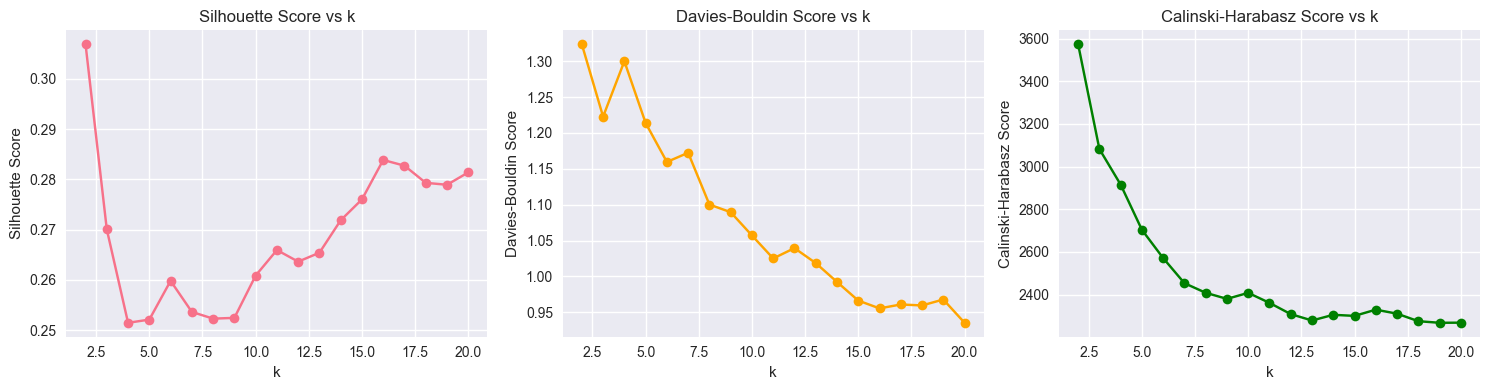

Лучшее k по Silhouette Score: 2
Количество кластеров: 2
Размеры кластеров: [4017 3983]


In [22]:
# Визуализация метрик KMeans
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(kmeans_df_2['k'], kmeans_df_2['silhouette'], marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k')
axes[0].grid(True)

axes[1].plot(kmeans_df_2['k'], kmeans_df_2['davies_bouldin'], marker='o', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Davies-Bouldin Score vs k')
axes[1].grid(True)

axes[2].plot(kmeans_df_2['k'], kmeans_df_2['calinski_harabasz'], marker='o', color='green')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz Score vs k')
axes[2].grid(True)

plt.tight_layout()
plt.savefig(figures_dir / 'ds2_kmeans_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Выбор лучшего k
best_k_2 = kmeans_df_2.loc[kmeans_df_2['silhouette'].idxmax(), 'k']
print(f"Лучшее k по Silhouette Score: {int(best_k_2)}")

# Обучение лучшей модели KMeans
kmeans_best_2 = KMeans(n_clusters=int(best_k_2), random_state=42, n_init=10)
labels_kmeans_2 = kmeans_best_2.fit_predict(X2_processed)

print(f"Количество кластеров: {len(np.unique(labels_kmeans_2))}")
print(f"Размеры кластеров: {np.bincount(labels_kmeans_2)}")

#### DBSCAN

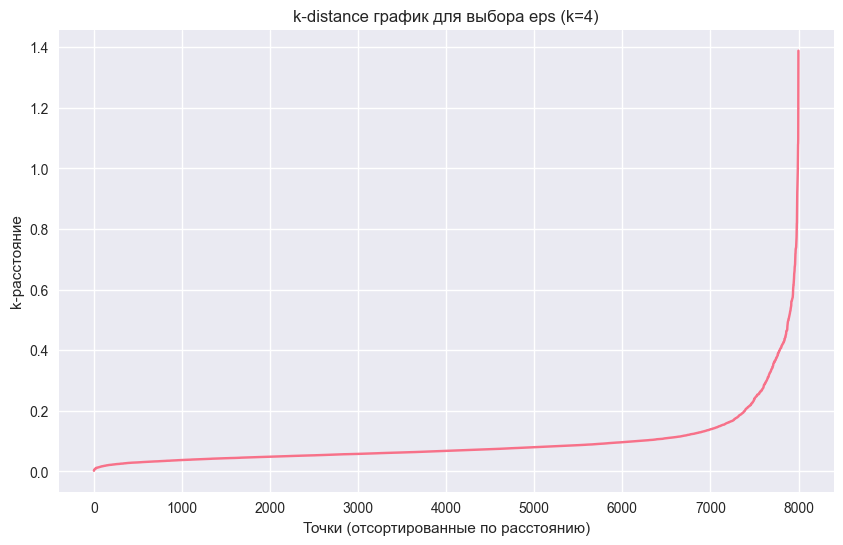

Предполагаемый eps (90-й перцентиль): 0.1607


In [23]:
# k-distance для DBSCAN
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X2_processed)
distances, indices = neighbors_fit.kneighbors(X2_processed)
distances = np.sort(distances, axis=0)
distances = distances[:, 1]

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Точки (отсортированные по расстоянию)')
plt.ylabel('k-расстояние')
plt.title('k-distance график для выбора eps (k=4)')
plt.grid(True)
plt.savefig(figures_dir / 'ds2_dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

eps_candidate = np.percentile(distances, 90)
print(f"Предполагаемый eps (90-й перцентиль): {eps_candidate:.4f}")

Результаты DBSCAN для датасета 2:
        eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  \
0  0.300000            3          30     0.059250   -0.300620        0.579598   
1  0.300000            4          11     0.067625    0.009053        0.548006   
2  0.300000            5           5     0.072375    0.085225        0.589699   
3  0.433333            3          40     0.034500   -0.221306        0.693376   
4  0.433333            4          27     0.045750   -0.231067        0.683611   
5  0.433333            5          11     0.057625   -0.067569        0.680550   
6  0.566667            3          14     0.014375    0.077280        0.782050   
7  0.566667            4          14     0.021000    0.134373        0.746213   
8  0.566667            5          15     0.027375    0.047405        0.829893   
9  0.700000            3           2     0.007125    0.345550        0.550987   

   calinski_harabasz  
0          16.826952  
1          21.790297  
2    

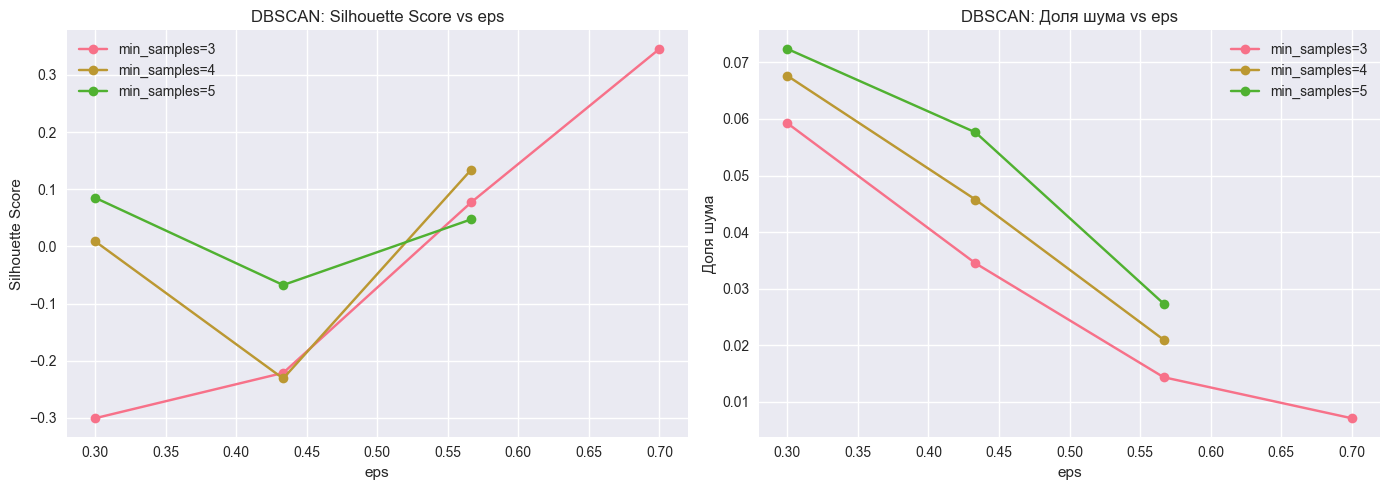


Лучшие параметры DBSCAN:
  eps: 0.7000
  min_samples: 3
  Доля шума: 0.0071


In [24]:
# Поиск оптимальных параметров DBSCAN
eps_range = np.linspace(0.3, 1.5, 10)
min_samples_range = [3, 4, 5]

dbscan_scores_2 = []

for eps, min_samples in product(eps_range, min_samples_range):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X2_processed)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)
    
    if n_clusters > 1:
        non_noise_mask = labels != -1
        if np.sum(non_noise_mask) > 1 and len(np.unique(labels[non_noise_mask])) > 1:
            sil = silhouette_score(X2_processed[non_noise_mask], labels[non_noise_mask])
            db = davies_bouldin_score(X2_processed[non_noise_mask], labels[non_noise_mask])
            ch = calinski_harabasz_score(X2_processed[non_noise_mask], labels[non_noise_mask])
        else:
            sil, db, ch = -1, np.inf, 0
    else:
        sil, db, ch = -1, np.inf, 0
    
    dbscan_scores_2.append({
        'eps': eps,
        'min_samples': min_samples,
        'n_clusters': n_clusters,
        'noise_ratio': noise_ratio,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch
    })

dbscan_df_2 = pd.DataFrame(dbscan_scores_2)
valid_results_2 = dbscan_df_2[dbscan_df_2['n_clusters'] > 1].copy()

if len(valid_results_2) > 0:
    print("Результаты DBSCAN для датасета 2:")
    print(valid_results_2.head(10))
    
    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ms in min_samples_range:
        subset = valid_results_2[valid_results_2['min_samples'] == ms]
        if len(subset) > 0:
            axes[0].plot(subset['eps'], subset['silhouette'], marker='o', label=f'min_samples={ms}')
    axes[0].set_xlabel('eps')
    axes[0].set_ylabel('Silhouette Score')
    axes[0].set_title('DBSCAN: Silhouette Score vs eps')
    axes[0].legend()
    axes[0].grid(True)
    
    for ms in min_samples_range:
        subset = valid_results_2[valid_results_2['min_samples'] == ms]
        if len(subset) > 0:
            axes[1].plot(subset['eps'], subset['noise_ratio'], marker='o', label=f'min_samples={ms}')
    axes[1].set_xlabel('eps')
    axes[1].set_ylabel('Доля шума')
    axes[1].set_title('DBSCAN: Доля шума vs eps')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig(figures_dir / 'ds2_dbscan_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    best_dbscan_2 = valid_results_2[
        (valid_results_2['noise_ratio'] < 0.3) & 
        (valid_results_2['silhouette'] > -1)
    ].loc[valid_results_2['silhouette'].idxmax()]
    
    print(f"\nЛучшие параметры DBSCAN:")
    print(f"  eps: {best_dbscan_2['eps']:.4f}")
    print(f"  min_samples: {int(best_dbscan_2['min_samples'])}")
    print(f"  Доля шума: {best_dbscan_2['noise_ratio']:.4f}")
    
    dbscan_best_2 = DBSCAN(
        eps=best_dbscan_2['eps'],
        min_samples=int(best_dbscan_2['min_samples'])
    )
    labels_dbscan_2 = dbscan_best_2.fit_predict(X2_processed)
else:
    print("Не найдено валидных результатов DBSCAN")
    best_dbscan_2 = None
    dbscan_best_2 = DBSCAN(eps=0.5, min_samples=4)
    labels_dbscan_2 = dbscan_best_2.fit_predict(X2_processed)

### Метрики качества

In [25]:
# Метрики для KMeans
metrics_kmeans_2 = {
    'silhouette': silhouette_score(X2_processed, labels_kmeans_2),
    'davies_bouldin': davies_bouldin_score(X2_processed, labels_kmeans_2),
    'calinski_harabasz': calinski_harabasz_score(X2_processed, labels_kmeans_2)
}

print("Метрики KMeans (датасет 2):")
for metric, value in metrics_kmeans_2.items():
    print(f"  {metric}: {value:.4f}")

# Метрики для DBSCAN
non_noise_mask_2 = labels_dbscan_2 != -1
if np.sum(non_noise_mask_2) > 1 and len(np.unique(labels_dbscan_2[non_noise_mask_2])) > 1:
    metrics_dbscan_2 = {
        'silhouette': silhouette_score(X2_processed[non_noise_mask_2], labels_dbscan_2[non_noise_mask_2]),
        'davies_bouldin': davies_bouldin_score(X2_processed[non_noise_mask_2], labels_dbscan_2[non_noise_mask_2]),
        'calinski_harabasz': calinski_harabasz_score(X2_processed[non_noise_mask_2], labels_dbscan_2[non_noise_mask_2]),
        'noise_ratio': np.sum(~non_noise_mask_2) / len(labels_dbscan_2)
    }
    print("\nМетрики DBSCAN (датасет 2, только non-noise точки):")
    for metric, value in metrics_dbscan_2.items():
        print(f"  {metric}: {value:.4f}")
else:
    metrics_dbscan_2 = {'silhouette': -1, 'davies_bouldin': np.inf, 'calinski_harabasz': 0, 'noise_ratio': 1.0}

Метрики KMeans (датасет 2):
  silhouette: 0.3069
  davies_bouldin: 1.3235
  calinski_harabasz: 3573.3933

Метрики DBSCAN (датасет 2, только non-noise точки):
  silhouette: 0.3455
  davies_bouldin: 0.5510
  calinski_harabasz: 10.4058
  noise_ratio: 0.0071


### Визуализация

Лучший метод: DBSCAN
Параметры: {'eps': np.float64(0.7), 'min_samples': 3}

Объяснённая дисперсия PCA: 0.7591


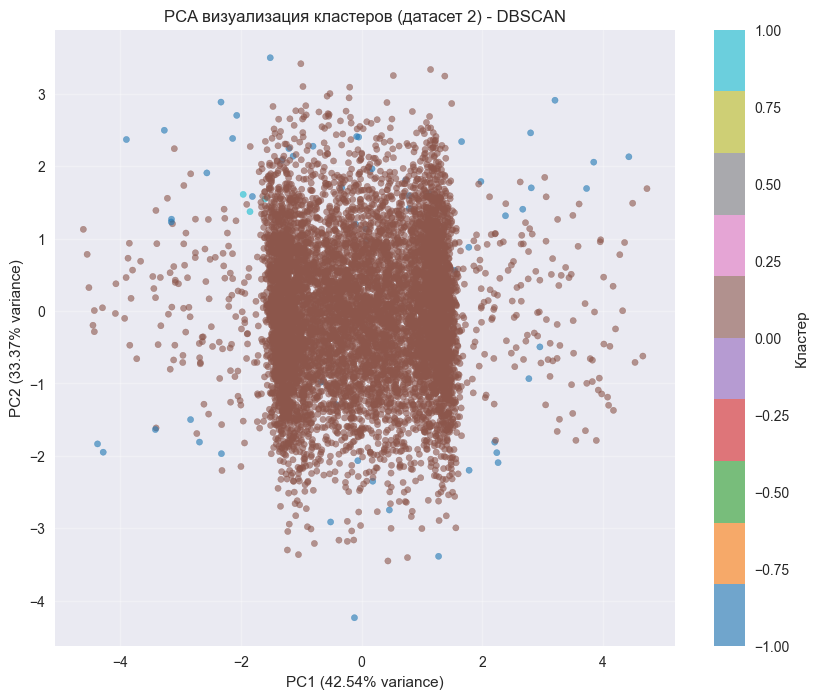

In [26]:
# Выбор лучшего метода
if metrics_kmeans_2['silhouette'] > metrics_dbscan_2.get('silhouette', -1):
    best_labels_2 = labels_kmeans_2
    best_method_2 = 'KMeans'
    best_params_2 = {'k': int(best_k_2)}
else:
    best_labels_2 = labels_dbscan_2
    best_method_2 = 'DBSCAN'
    best_params_2 = {'eps': best_dbscan_2['eps'], 'min_samples': int(best_dbscan_2['min_samples'])} if best_dbscan_2 is not None else {}

print(f"Лучший метод: {best_method_2}")
print(f"Параметры: {best_params_2}")

# PCA для визуализации (хотя данных всего 3 признака, используем PCA для единообразия)
pca_2 = PCA(n_components=2, random_state=42)
X2_pca = pca_2.fit_transform(X2_processed)

print(f"\nОбъяснённая дисперсия PCA: {pca_2.explained_variance_ratio_.sum():.4f}")

# PCA scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X2_pca[:, 0], X2_pca[:, 1], c=best_labels_2, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Кластер')
plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'PCA визуализация кластеров (датасет 2) - {best_method_2}')
plt.grid(True, alpha=0.3)
plt.savefig(figures_dir / 'ds2_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### Итог по датасету 2

In [27]:
print("="*60)
print("ИТОГ ПО ДАТАСЕТУ 2")
print("="*60)
print(f"\nЛучший метод: {best_method_2}")
print(f"Параметры: {best_params_2}")

if best_method_2 == 'KMeans':
    print(f"\nМетрики:")
    for metric, value in metrics_kmeans_2.items():
        print(f"  {metric}: {value:.4f}")
else:
    print(f"\nМетрики (только non-noise точки):")
    for metric, value in metrics_dbscan_2.items():
        print(f"  {metric}: {value:.4f}")

print("\nВыводы:")
print("- Датасет содержит нелинейную структуру и выбросы")
print("- Наличие шумового признака z_noise усложняет кластеризацию")
print("- DBSCAN может лучше справляться с нелинейными структурами")
print("- KMeans может страдать из-за предположения о сферических кластерах")

ИТОГ ПО ДАТАСЕТУ 2

Лучший метод: DBSCAN
Параметры: {'eps': np.float64(0.7), 'min_samples': 3}

Метрики (только non-noise точки):
  silhouette: 0.3455
  davies_bouldin: 0.5510
  calinski_harabasz: 10.4058
  noise_ratio: 0.0071

Выводы:
- Датасет содержит нелинейную структуру и выбросы
- Наличие шумового признака z_noise усложняет кластеризацию
- DBSCAN может лучше справляться с нелинейными структурами
- KMeans может страдать из-за предположения о сферических кластерах


## Датасет 3

### Загрузка данных и первичный анализ

In [28]:
df3 = pd.read_csv('data/S07-hw-dataset-03.csv')

print(f"Размер датасета: {df3.shape}")
print(f"\nПервые строки:")
df3.head()

Размер датасета: (15000, 5)

Первые строки:


,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776
3,3,6.854042,1.560181,1.760614,-1.230946
4,4,9.963812,-8.869921,2.966583,0.915899


In [29]:
print("Информация о датасете:")
df3.info()
print("\n" + "="*50)
print("\nБазовые статистики:")
df3.describe()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB


Базовые статистики:


,sample_id,x1,x2,f_corr,f_noise
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.246296,1.033764,0.212776,-0.027067
std,4330.271354,4.592421,4.710791,1.530017,2.506375
min,0.000000,-9.995585,-9.980853,-5.212038,-8.785884
25%,3749.750000,-1.782144,-2.666393,-0.966224,-1.731128
50%,7499.500000,0.664226,1.831257,0.296508,-0.052391
75%,11249.250000,4.435671,4.969630,1.390273,1.673831
max,14999.000000,16.207863,14.271153,5.795876,11.266865


In [30]:
missing = df3.isnull().sum()
missing_pct = (missing / len(df3)) * 100
print("Пропуски:")
print(pd.DataFrame({'Количество': missing, 'Процент': missing_pct}))

sample_id_3 = df3['sample_id'].copy()
X3 = df3.drop('sample_id', axis=1).copy()

print(f"\nПризнаки (X3): {list(X3.columns)}")
print(f"Типы признаков: все числовые")
print(f"Размер X3: {X3.shape}")

Пропуски:
           Количество  Процент
sample_id           0      0.0
x1                  0      0.0
x2                  0      0.0
f_corr              0      0.0
f_noise             0      0.0

Признаки (X3): ['x1', 'x2', 'f_corr', 'f_noise']
Типы признаков: все числовые
Размер X3: (15000, 4)


### Препроцессинг

In [31]:
preprocessor_3 = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

X3_processed = preprocessor_3.fit_transform(X3)
print(f"Размер после препроцессинга: {X3_processed.shape}")
print(f"Среднее: {X3_processed.mean(axis=0).round(4)}")
print(f"Стд. отклонение: {X3_processed.std(axis=0).round(4)}")

Размер после препроцессинга: (15000, 4)
Среднее: [ 0. -0.  0. -0.]
Стд. отклонение: [1. 1. 1. 1.]


### Модели кластеризации

#### KMeans

Результаты KMeans для датасета 3:
    k  silhouette  davies_bouldin  calinski_harabasz
0   2    0.298905        1.355468        7004.795630
1   3    0.315545        1.157726        6957.162640
2   4    0.314619        1.159676        6492.278931
3   5    0.299297        1.168556        6125.127993
4   6    0.293149        1.140769        6097.475389
5   7    0.279853        1.218465        5858.344907
6   8    0.289491        1.147231        5630.838101
7   9    0.284791        1.123538        5543.965528
8  10    0.278895        1.143786        5386.123819
9  11    0.276319        1.142855        5207.368057


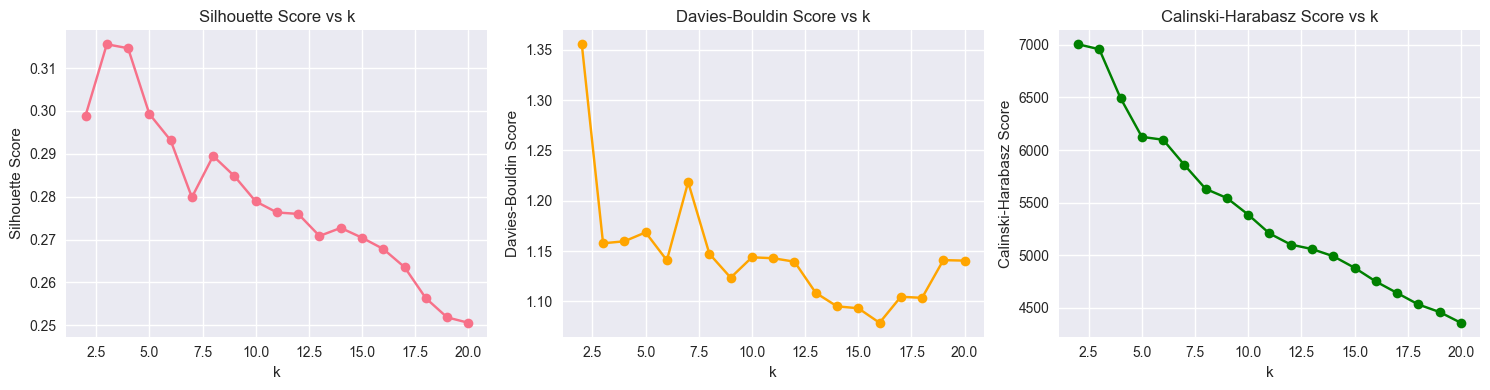

Лучшее k по Silhouette Score: 3
Количество кластеров: 3
Размеры кластеров: [6417 4903 3680]


In [32]:
# Подбор оптимального k для KMeans
k_range = range(2, 21)
kmeans_scores_3 = {'k': [], 'silhouette': [], 'davies_bouldin': [], 'calinski_harabasz': []}

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X3_processed)
    
    if len(np.unique(labels)) > 1:
        sil = silhouette_score(X3_processed, labels)
        db = davies_bouldin_score(X3_processed, labels)
        ch = calinski_harabasz_score(X3_processed, labels)
        
        kmeans_scores_3['k'].append(k)
        kmeans_scores_3['silhouette'].append(sil)
        kmeans_scores_3['davies_bouldin'].append(db)
        kmeans_scores_3['calinski_harabasz'].append(ch)

kmeans_df_3 = pd.DataFrame(kmeans_scores_3)
print("Результаты KMeans для датасета 3:")
print(kmeans_df_3.head(10))

# Визуализация метрик KMeans
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(kmeans_df_3['k'], kmeans_df_3['silhouette'], marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k')
axes[0].grid(True)

axes[1].plot(kmeans_df_3['k'], kmeans_df_3['davies_bouldin'], marker='o', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Davies-Bouldin Score vs k')
axes[1].grid(True)

axes[2].plot(kmeans_df_3['k'], kmeans_df_3['calinski_harabasz'], marker='o', color='green')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz Score vs k')
axes[2].grid(True)

plt.tight_layout()
plt.savefig(figures_dir / 'ds3_kmeans_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Выбор лучшего k
best_k_3 = kmeans_df_3.loc[kmeans_df_3['silhouette'].idxmax(), 'k']
print(f"Лучшее k по Silhouette Score: {int(best_k_3)}")

# Обучение лучшей модели KMeans
kmeans_best_3 = KMeans(n_clusters=int(best_k_3), random_state=42, n_init=10)
labels_kmeans_3 = kmeans_best_3.fit_predict(X3_processed)
print(f"Количество кластеров: {len(np.unique(labels_kmeans_3))}")
print(f"Размеры кластеров: {np.bincount(labels_kmeans_3)}")

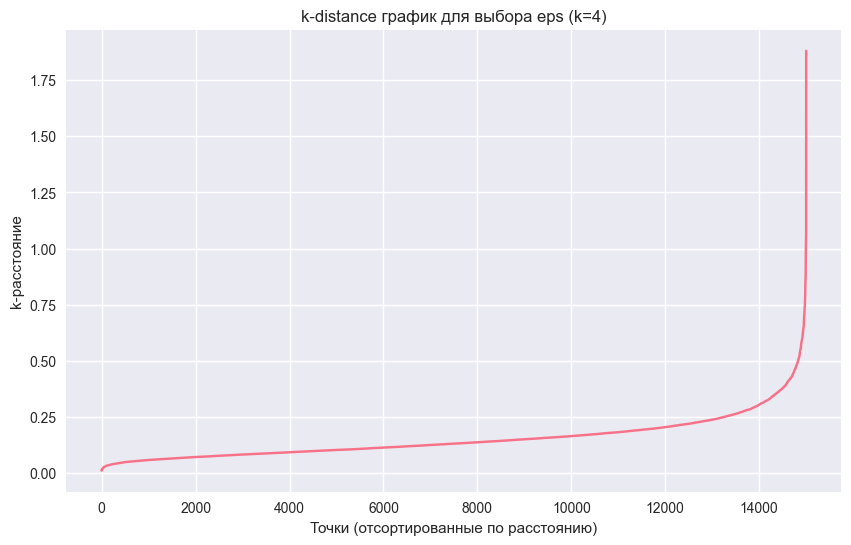

Предполагаемый eps (90-й перцентиль): 0.2644
Результаты DBSCAN для датасета 3:
        eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  \
0  0.300000            3          70     0.086800   -0.433968        0.860778   
1  0.300000            4          39     0.105400   -0.329702        0.904043   
2  0.300000            5          22     0.125333   -0.236076        0.930436   
3  0.433333            3          24     0.025800   -0.347831        0.768583   
4  0.433333            4          13     0.031667   -0.200545        0.832497   
5  0.433333            5           7     0.036667   -0.162907        0.961838   
6  0.566667            3           6     0.009667   -0.111244        0.705552   
7  0.566667            4           4     0.011600   -0.026498        0.850578   
8  0.566667            5           4     0.013067   -0.039531        0.872792   
9  0.700000            3           3     0.002933    0.231532        0.596745   

   calinski_harabasz  
0     

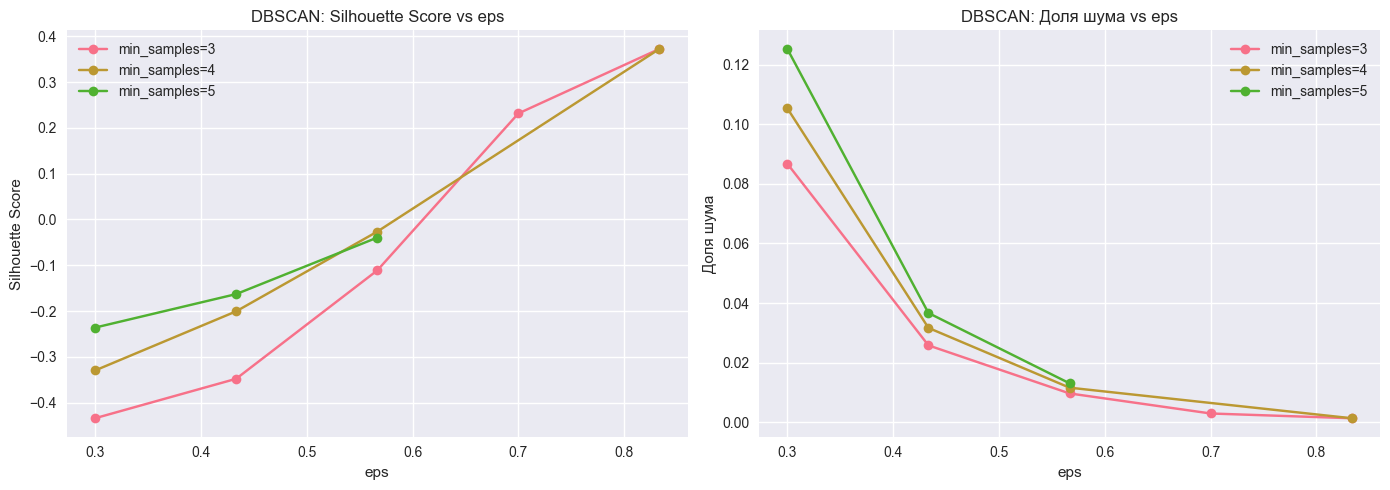


Лучшие параметры DBSCAN:
  eps: 0.8333
  min_samples: 3
  Доля шума: 0.0013


In [33]:
# k-distance для DBSCAN
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X3_processed)
distances, indices = neighbors_fit.kneighbors(X3_processed)
distances = np.sort(distances, axis=0)
distances = distances[:, 1]

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Точки (отсортированные по расстоянию)')
plt.ylabel('k-расстояние')
plt.title('k-distance график для выбора eps (k=4)')
plt.grid(True)
plt.savefig(figures_dir / 'ds3_dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

eps_candidate = np.percentile(distances, 90)
print(f"Предполагаемый eps (90-й перцентиль): {eps_candidate:.4f}")

# Поиск оптимальных параметров DBSCAN
eps_range = np.linspace(0.3, 1.5, 10)
min_samples_range = [3, 4, 5]

dbscan_scores_3 = []

for eps, min_samples in product(eps_range, min_samples_range):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X3_processed)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)
    
    if n_clusters > 1:
        non_noise_mask = labels != -1
        if np.sum(non_noise_mask) > 1 and len(np.unique(labels[non_noise_mask])) > 1:
            sil = silhouette_score(X3_processed[non_noise_mask], labels[non_noise_mask])
            db = davies_bouldin_score(X3_processed[non_noise_mask], labels[non_noise_mask])
            ch = calinski_harabasz_score(X3_processed[non_noise_mask], labels[non_noise_mask])
        else:
            sil, db, ch = -1, np.inf, 0
    else:
        sil, db, ch = -1, np.inf, 0
    
    dbscan_scores_3.append({
        'eps': eps,
        'min_samples': min_samples,
        'n_clusters': n_clusters,
        'noise_ratio': noise_ratio,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch
    })

dbscan_df_3 = pd.DataFrame(dbscan_scores_3)
valid_results_3 = dbscan_df_3[dbscan_df_3['n_clusters'] > 1].copy()

if len(valid_results_3) > 0:
    print("Результаты DBSCAN для датасета 3:")
    print(valid_results_3.head(10))
    
    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ms in min_samples_range:
        subset = valid_results_3[valid_results_3['min_samples'] == ms]
        if len(subset) > 0:
            axes[0].plot(subset['eps'], subset['silhouette'], marker='o', label=f'min_samples={ms}')
    axes[0].set_xlabel('eps')
    axes[0].set_ylabel('Silhouette Score')
    axes[0].set_title('DBSCAN: Silhouette Score vs eps')
    axes[0].legend()
    axes[0].grid(True)
    
    for ms in min_samples_range:
        subset = valid_results_3[valid_results_3['min_samples'] == ms]
        if len(subset) > 0:
            axes[1].plot(subset['eps'], subset['noise_ratio'], marker='o', label=f'min_samples={ms}')
    axes[1].set_xlabel('eps')
    axes[1].set_ylabel('Доля шума')
    axes[1].set_title('DBSCAN: Доля шума vs eps')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig(figures_dir / 'ds3_dbscan_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    best_dbscan_3 = valid_results_3[
        (valid_results_3['noise_ratio'] < 0.3) & 
        (valid_results_3['silhouette'] > -1)
    ].loc[valid_results_3['silhouette'].idxmax()]
    
    print(f"\nЛучшие параметры DBSCAN:")
    print(f"  eps: {best_dbscan_3['eps']:.4f}")
    print(f"  min_samples: {int(best_dbscan_3['min_samples'])}")
    print(f"  Доля шума: {best_dbscan_3['noise_ratio']:.4f}")
    
    dbscan_best_3 = DBSCAN(
        eps=best_dbscan_3['eps'],
        min_samples=int(best_dbscan_3['min_samples'])
    )
    labels_dbscan_3 = dbscan_best_3.fit_predict(X3_processed)
else:
    print("Не найдено валидных результатов DBSCAN")
    best_dbscan_3 = None
    dbscan_best_3 = DBSCAN(eps=0.5, min_samples=4)
    labels_dbscan_3 = dbscan_best_3.fit_predict(X3_processed)

In [34]:
# Метрики для KMeans
metrics_kmeans_3 = {
    'silhouette': silhouette_score(X3_processed, labels_kmeans_3),
    'davies_bouldin': davies_bouldin_score(X3_processed, labels_kmeans_3),
    'calinski_harabasz': calinski_harabasz_score(X3_processed, labels_kmeans_3)
}

print("Метрики KMeans (датасет 3):")
for metric, value in metrics_kmeans_3.items():
    print(f"  {metric}: {value:.4f}")

# Метрики для DBSCAN
non_noise_mask_3 = labels_dbscan_3 != -1
if np.sum(non_noise_mask_3) > 1 and len(np.unique(labels_dbscan_3[non_noise_mask_3])) > 1:
    metrics_dbscan_3 = {
        'silhouette': silhouette_score(X3_processed[non_noise_mask_3], labels_dbscan_3[non_noise_mask_3]),
        'davies_bouldin': davies_bouldin_score(X3_processed[non_noise_mask_3], labels_dbscan_3[non_noise_mask_3]),
        'calinski_harabasz': calinski_harabasz_score(X3_processed[non_noise_mask_3], labels_dbscan_3[non_noise_mask_3]),
        'noise_ratio': np.sum(~non_noise_mask_3) / len(labels_dbscan_3)
    }
    print("\nМетрики DBSCAN (датасет 3, только non-noise точки):")
    for metric, value in metrics_dbscan_3.items():
        print(f"  {metric}: {value:.4f}")
else:
    metrics_dbscan_3 = {'silhouette': -1, 'davies_bouldin': np.inf, 'calinski_harabasz': 0, 'noise_ratio': 1.0}

Метрики KMeans (датасет 3):
  silhouette: 0.3155
  davies_bouldin: 1.1577
  calinski_harabasz: 6957.1626

Метрики DBSCAN (датасет 3, только non-noise точки):
  silhouette: 0.3725
  davies_bouldin: 0.5511
  calinski_harabasz: 17.1897
  noise_ratio: 0.0013


### Визуализация

Лучший метод: DBSCAN
Параметры: {'eps': np.float64(0.8333333333333333), 'min_samples': 3}

Объяснённая дисперсия PCA: 0.7192


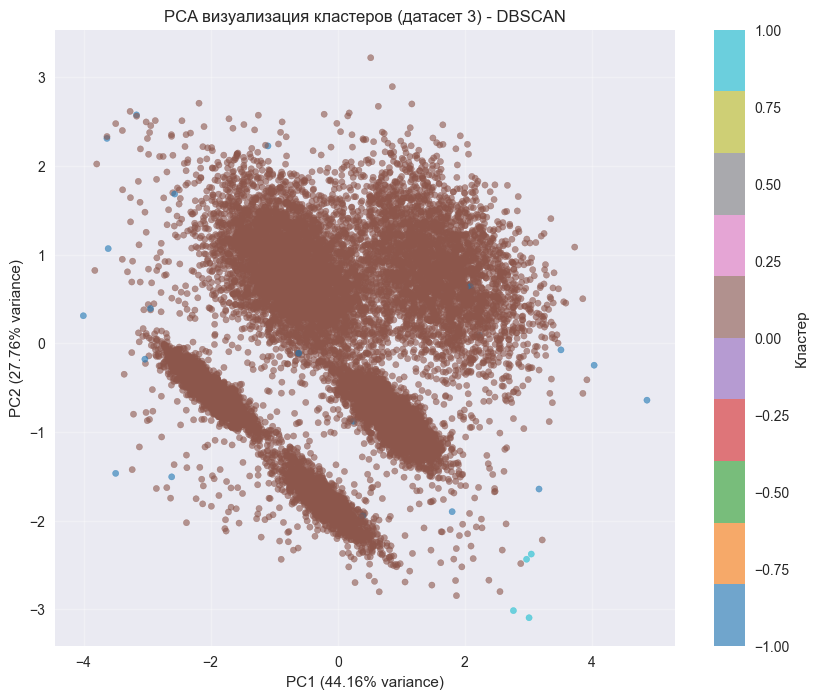

In [35]:
# Выбор лучшего метода
if metrics_kmeans_3['silhouette'] > metrics_dbscan_3.get('silhouette', -1):
    best_labels_3 = labels_kmeans_3
    best_method_3 = 'KMeans'
    best_params_3 = {'k': int(best_k_3)}
else:
    best_labels_3 = labels_dbscan_3
    best_method_3 = 'DBSCAN'
    best_params_3 = {'eps': best_dbscan_3['eps'], 'min_samples': int(best_dbscan_3['min_samples'])} if best_dbscan_3 is not None else {}

print(f"Лучший метод: {best_method_3}")
print(f"Параметры: {best_params_3}")

# PCA для визуализации
pca_3 = PCA(n_components=2, random_state=42)
X3_pca = pca_3.fit_transform(X3_processed)

print(f"\nОбъяснённая дисперсия PCA: {pca_3.explained_variance_ratio_.sum():.4f}")

# PCA scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X3_pca[:, 0], X3_pca[:, 1], c=best_labels_3, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Кластер')
plt.xlabel(f'PC1 ({pca_3.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_3.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'PCA визуализация кластеров (датасет 3) - {best_method_3}')
plt.grid(True, alpha=0.3)
plt.savefig(figures_dir / 'ds3_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### Устойчивость (для датасета 1)

Средний ARI между запусками: 1.0000
Стд. отклонение ARI: 0.0000
Минимальный ARI: 1.0000
Максимальный ARI: 1.0000


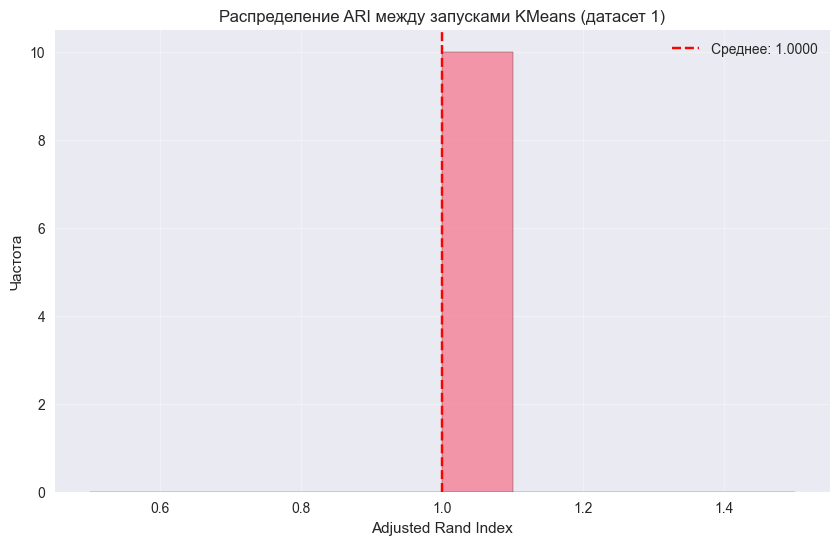


Выводы по устойчивости:
- KMeans показывает высокую устойчивость (ARI > 0.9)
- Разные random_state дают очень похожие результаты


In [36]:
# Проверка устойчивости KMeans на датасете 1
n_runs = 5
random_states = [42, 123, 456, 789, 999]
ari_scores = []

labels_list = []
for rs in random_states:
    kmeans = KMeans(n_clusters=int(best_k_1), random_state=rs, n_init=10)
    labels = kmeans.fit_predict(X1_processed)
    labels_list.append(labels)

# Вычисление ARI между всеми парами запусков
for i in range(n_runs):
    for j in range(i+1, n_runs):
        ari = adjusted_rand_score(labels_list[i], labels_list[j])
        ari_scores.append(ari)

ari_scores = np.array(ari_scores)
print(f"Средний ARI между запусками: {ari_scores.mean():.4f}")
print(f"Стд. отклонение ARI: {ari_scores.std():.4f}")
print(f"Минимальный ARI: {ari_scores.min():.4f}")
print(f"Максимальный ARI: {ari_scores.max():.4f}")

# Визуализация устойчивости
plt.figure(figsize=(10, 6))
plt.hist(ari_scores, bins=10, alpha=0.7, edgecolor='black')
plt.xlabel('Adjusted Rand Index')
plt.ylabel('Частота')
plt.title('Распределение ARI между запусками KMeans (датасет 1)')
plt.axvline(ari_scores.mean(), color='red', linestyle='--', label=f'Среднее: {ari_scores.mean():.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(figures_dir / 'ds1_stability.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nВыводы по устойчивости:")
if ari_scores.mean() > 0.9:
    print("- KMeans показывает высокую устойчивость (ARI > 0.9)")
    print("- Разные random_state дают очень похожие результаты")
else:
    print("- KMeans показывает среднюю/низкую устойчивость")
    print("- Результаты могут сильно зависеть от инициализации")

### Итог по датасету 3

In [37]:
print("="*60)
print("ИТОГ ПО ДАТАСЕТУ 3")
print("="*60)
print(f"\nЛучший метод: {best_method_3}")
print(f"Параметры: {best_params_3}")

if best_method_3 == 'KMeans':
    print(f"\nМетрики:")
    for metric, value in metrics_kmeans_3.items():
        print(f"  {metric}: {value:.4f}")
else:
    print(f"\nМетрики (только non-noise точки):")
    for metric, value in metrics_dbscan_3.items():
        print(f"  {metric}: {value:.4f}")

print("\nВыводы:")
print("- Датасет содержит кластеры разной плотности и фоновый шум")
print("- DBSCAN может лучше справляться с разной плотностью кластеров")
print("- Подбор eps критичен для DBSCAN на таких данных")
print("- KMeans может объединять кластеры разной плотности")

ИТОГ ПО ДАТАСЕТУ 3

Лучший метод: DBSCAN
Параметры: {'eps': np.float64(0.8333333333333333), 'min_samples': 3}

Метрики (только non-noise точки):
  silhouette: 0.3725
  davies_bouldin: 0.5511
  calinski_harabasz: 17.1897
  noise_ratio: 0.0013

Выводы:
- Датасет содержит кластеры разной плотности и фоновый шум
- DBSCAN может лучше справляться с разной плотностью кластеров
- Подбор eps критичен для DBSCAN на таких данных
- KMeans может объединять кластеры разной плотности


## Сохранение артефактов

### Метрики и конфигурации

In [38]:
# Сводка метрик
metrics_summary = {
    'dataset_1': {
        'KMeans': metrics_kmeans_1,
        'DBSCAN': metrics_dbscan_1
    },
    'dataset_2': {
        'KMeans': metrics_kmeans_2,
        'DBSCAN': metrics_dbscan_2
    },
    'dataset_3': {
        'KMeans': metrics_kmeans_3,
        'DBSCAN': metrics_dbscan_3
    }
}

# Преобразование numpy типов в Python типы для JSON
def convert_to_serializable(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(item) for item in obj]
    return obj

metrics_summary_serializable = convert_to_serializable(metrics_summary)

with open(artifacts_dir / 'metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_summary_serializable, f, indent=2, ensure_ascii=False)

print("Метрики сохранены в metrics_summary.json")

Метрики сохранены в metrics_summary.json


In [39]:
# Лучшие конфигурации
best_configs = {
    'dataset_1': {
        'method': best_method_1,
        'parameters': best_params_1,
        'criterion': 'silhouette_score'
    },
    'dataset_2': {
        'method': best_method_2,
        'parameters': best_params_2,
        'criterion': 'silhouette_score'
    },
    'dataset_3': {
        'method': best_method_3,
        'parameters': best_params_3,
        'criterion': 'silhouette_score'
    }
}

best_configs_serializable = convert_to_serializable(best_configs)

with open(artifacts_dir / 'best_configs.json', 'w', encoding='utf-8') as f:
    json.dump(best_configs_serializable, f, indent=2, ensure_ascii=False)

print("Лучшие конфигурации сохранены в best_configs.json")
print("\nЛучшие конфигурации:")
for ds, config in best_configs.items():
    print(f"\n{ds}:")
    print(f"  Метод: {config['method']}")
    print(f"  Параметры: {config['parameters']}")

Лучшие конфигурации сохранены в best_configs.json

Лучшие конфигурации:

dataset_1:
  Метод: DBSCAN
  Параметры: {'eps': np.float64(1.8333333333333333), 'min_samples': 3}

dataset_2:
  Метод: DBSCAN
  Параметры: {'eps': np.float64(0.7), 'min_samples': 3}

dataset_3:
  Метод: DBSCAN
  Параметры: {'eps': np.float64(0.8333333333333333), 'min_samples': 3}


### Сохранение меток кластеров

In [41]:
# Сохранение меток для лучших решений
labels_df_1 = pd.DataFrame({
    'sample_id': sample_id_1,
    'cluster_label': best_labels_1
})
labels_df_1.to_csv(labels_dir / 'labels_hw07_ds1.csv', index=False)
print("Метки для датасета 1 сохранены")

labels_df_2 = pd.DataFrame({
    'sample_id': sample_id_2,
    'cluster_label': best_labels_2
})
labels_df_2.to_csv(labels_dir / 'labels_hw07_ds2.csv', index=False)
print("Метки для датасета 2 сохранены")

labels_df_3 = pd.DataFrame({
    'sample_id': sample_id_3,
    'cluster_label': best_labels_3
})
labels_df_3.to_csv(labels_dir / 'labels_hw07_ds3.csv', index=False)
print("Метки для датасета 3 сохранены")

print("\nВсе артефакты сохранены!")

Метки для датасета 1 сохранены
Метки для датасета 2 сохранены
Метки для датасета 3 сохранены

Все артефакты сохранены!
